# Problem: Implement an LSTM Model 

### Problem Statement
You are tasked with implementing a simple **LSTM (Long Short-Term Memory)** model in PyTorch. The model should process sequential data using an LSTM layer followed by a fully connected (FC) layer. Your goal is two-fold: one is to implement a LSTM layer from scratch and another using inbuilt pytorch LSTM layer. Compare the results implementing the forward passes for both the LSTM models.

### Requirements
1. **Define the LSTM Model using Custom LSTM layer**:
   - Add a `Custom` LSTM layer to the model. The layer must take care of the hidden and cell states
   - Add a **fully connected (FC) layer** that maps the output of the LSTM to the final predictions.
   - Implement the `forward` method to:
     - Pass the input sequence through the LSTM.
     - Feed the output of the LSTM into the fully connected layer for the final output.

2. **Define the LSTM Model using in-built LSTM layer**:
  - Same as `1` with only difference that this time define the LSTM layer using pytorch `nn.Module`

### Constraints
- The LSTM layer should be implemented with a single hidden layer.
- Use a suitable number of input features, hidden units, and output size for the task.
- Make sure the `forward` method returns the output of the fully connected layer after processing the LSTM output.


<details>
  <summary>💡 Hint</summary>
  Add the LSTM layer and FC layer in LSTMModel.__init__.
  <br>
  Implement the forward pass to process sequences using the LSTM and FC layers.
  <br> Review Hidden and cell states computation here: [D2l.ai](https://d2l.ai/chapter_recurrent-modern/lstm.html)
</details>

In [31]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [32]:
# Generate synthetic sequential data
torch.manual_seed(42)
sequence_length = 10
num_samples = 100

# Create a sine wave dataset
X = torch.linspace(0, 4 * 3.14159, steps=num_samples).unsqueeze(1)
y = torch.sin(X)

# Prepare data for LSTM
def create_in_out_sequences(data, seq_length):
    in_seq = []
    out_seq = []
    for i in range(len(data) - seq_length):
        in_seq.append(data[i:i + seq_length])
        out_seq.append(data[i + seq_length])
    return torch.stack(in_seq), torch.stack(out_seq)

X_seq, y_seq = create_in_out_sequences(y, sequence_length)

In [33]:
class CustomLSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_units, output_dim=1):
        super(CustomLSTMModel, self).__init__()
        self.input_dim = input_dim
        self.hidden_units = hidden_units
        self.output_dim = output_dim
        self.Wxi = nn.Parameter(torch.randn(input_dim, hidden_units) * 0.1)
        self.Whi = nn.Parameter(torch.randn(hidden_units, hidden_units) * 0.1)
        self.bi = nn.Parameter(torch.zeros(hidden_units))
        self.Wxf = nn.Parameter(torch.randn(input_dim, hidden_units) * 0.1)
        self.Whf = nn.Parameter(torch.randn(hidden_units, hidden_units) * 0.1)
        self.bf = nn.Parameter(torch.zeros(hidden_units))
        self.Wxo = nn.Parameter(torch.randn(input_dim, hidden_units) * 0.1)
        self.Who = nn.Parameter(torch.randn(hidden_units, hidden_units) * 0.1)
        self.bo = nn.Parameter(torch.zeros(hidden_units))
        self.Wxc = nn.Parameter(torch.randn(input_dim, hidden_units) * 0.1)
        self.Whc = nn.Parameter(torch.randn(hidden_units, hidden_units) * 0.1)
        self.bc = nn.Parameter(torch.zeros(hidden_units))
        self.fc = nn.Linear(hidden_units, output_dim)
    def forward(self, inputs, H_C=None):
        batch_size, seq_len, _ = inputs.shape
        if H_C is None:
            H = torch.zeros(batch_size, self.hidden_units, device=inputs.device)
            C = torch.zeros(batch_size, self.hidden_units, device=inputs.device)
        else:
            H, C = H_C
        all_hidden_states = []
        for t in range(seq_len):
            X_t = inputs[:, t, :]
            I_t = torch.sigmoid(X_t @ self.Wxi + H @ self.Whi + self.bi)
            F_t = torch.sigmoid(X_t @ self.Wxf + H @ self.Whf + self.bf)
            O_t = torch.sigmoid(X_t @ self.Wxo + H @ self.Who + self.bo)
            C_tilde = torch.tanh(X_t @ self.Wxc + H @ self.Whc + self.bc)
            C = F_t * C + I_t * C_tilde
            H = O_t * torch.tanh(C)
            all_hidden_states.append(H.unsqueeze(1))
        outputs = torch.cat(all_hidden_states, dim=1)
        # Only use the last hidden state for prediction (like nn.LSTM)
        pred = self.fc(outputs[:, -1, :])
        return pred, (H, C)

In [34]:
# Define the LSTM Model
# TODO: Add LSTM layer, forward implementation
class LSTMModel(nn.Module):
    def __init__(self):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=50, num_layers=1, batch_first=True)
        self.fc = nn.Linear(50, 1)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        pred = self.fc(lstm_out[:, -1, :])  # Use the last output of the LSTM
        return pred
# Initialize the model, loss function, and optimizer
model = LSTMModel()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [35]:
# Initialize the model, loss function, and optimizer
model_custom = CustomLSTMModel(1, 50)
model_inbuilt = LSTMModel()
criterion = nn.MSELoss()
optimizer_custom = optim.Adam(model_custom.parameters(), lr=0.01)
optimizer_inbuilt = optim.Adam(model_inbuilt.parameters(), lr=0.01)

In [40]:
# Training loop for the custom model
epochs = 500
for epoch in range(epochs):
    # Forward pass
    state = None
    pred, state = model_custom(X_seq, state)
    loss = criterion(pred, y_seq)  # pred shape: (batch, 1), y_seq shape: (batch, 1)
    # Backward pass and optimization
    optimizer_custom.zero_grad()
    loss.backward()
    optimizer_custom.step()

    # Log progress every 50 epochs
    if (epoch + 1) % 50 == 0:
        print(f"Epoch [{epoch + 1}/{epochs}], Loss: {loss.item():.4f}")

Epoch [50/500], Loss: 0.0003
Epoch [100/500], Loss: 0.0000
Epoch [150/500], Loss: 0.0000
Epoch [200/500], Loss: 0.0000
Epoch [250/500], Loss: 0.0000
Epoch [300/500], Loss: 0.0000
Epoch [350/500], Loss: 0.0000
Epoch [400/500], Loss: 0.0000
Epoch [450/500], Loss: 0.0000
Epoch [500/500], Loss: 0.0000


In [41]:
# Training loop for the inbuilt model
epochs = 500
for epoch in range(epochs):
    # Forward pass
    pred = model_inbuilt(X_seq)
    loss = criterion(pred, y_seq)
    # Backward pass and optimization
    optimizer_inbuilt.zero_grad()
    loss.backward()
    optimizer_inbuilt.step()

    # Log progress every 50 epochs
    if (epoch + 1) % 50 == 0:
        print(f"Epoch [{epoch + 1}/{epochs}], Loss: {loss.item():.4f}")

Epoch [50/500], Loss: 0.0000
Epoch [100/500], Loss: 0.0000
Epoch [150/500], Loss: 0.0000
Epoch [200/500], Loss: 0.0000
Epoch [250/500], Loss: 0.0000
Epoch [300/500], Loss: 0.0000
Epoch [350/500], Loss: 0.0000
Epoch [400/500], Loss: 0.0000
Epoch [450/500], Loss: 0.0000
Epoch [500/500], Loss: 0.0000


In [50]:
# Testing on new data
test_steps = 100  # Ensure this is greater than sequence_length
X_test = torch.linspace(0, 5 * 3.14159, steps=test_steps).unsqueeze(1)
y_test = torch.sin(X_test)

# Create test input sequences
X_test_seq, _ = create_in_out_sequences(y_test, sequence_length)

with torch.no_grad():
    pred_custom, _ = model_custom(X_test_seq)
    pred_inbuilt = model_inbuilt(X_test_seq)
pred_custom = pred_custom.squeeze()
pred_inbuilt = pred_inbuilt.squeeze()
print(f"Predictions with Custom Model for new sequence: {pred_custom.tolist()}")
print(f"Predictions with In-Built Model: {pred_inbuilt.tolist()}")

Predictions with Custom Model for new sequence: [1.0358452796936035, 1.0248618125915527, 0.9886074066162109, 0.9275968670845032, 0.8428504467010498, 0.7359795570373535, 0.6093541383743286, 0.4662367105484009, 0.3107512593269348, 0.1476118117570877, -0.018327942118048668, -0.18250398337841034, -0.340850830078125, -0.4897611737251282, -0.6259433031082153, -0.7463443875312805, -0.8481959104537964, -0.9291362166404724, -0.987319827079773, -1.0214474201202393, -1.0307062864303589, -1.0146797895431519, -0.9733048677444458, -0.9069258570671082, -0.8164389133453369, -0.7035058736801147, -0.5707782506942749, -0.42202651500701904, -0.26203545928001404, -0.09617818146944046, 0.07023915648460388, 0.2325798124074936, 0.38712137937545776, 0.5308852195739746, 0.6612785458564758, 0.7758272290229797, 0.8721112012863159, 0.9478557705879211, 1.0010862350463867, 1.0302836894989014, 1.034496784210205, 1.0133757591247559, 0.9671303629875183, 0.8964741230010986, 0.802647054195404, 0.6875427961349487, 0.55387

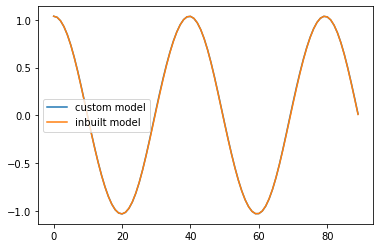

In [53]:
#Plot the predictions
plt.figure()
# plt.plot(y_test, label="Ground Truth")
plt.plot(pred_custom, label="custom model")
plt.plot(pred_inbuilt, label="inbuilt model")
plt.legend()
plt.show()